---
numbering: false
---

# 10.4. Principal Components Analysis

## Introduction

In [Chapter 10.3](./03-best-direction.ipynb), we found the best direction for representing data by minimizing orthogonal projection error (equivalently, maximizing projected variance). We now use that result to define principal components and connect them to the SVD.


---

## Principal Components

We've discovered that the single best direction to project the data onto is the eigenvector of $\tilde X^T \tilde X$ corresponding to the largest eigenvalue of $\tilde X^T \tilde X$. Let's call this eigenvector $\vec v_1$, as I did in the diagram above. More $\vec v$'s are coming.

$$\text{PV}(\vec v) = \frac{1}{n} \lVert \tilde X \vec v \rVert^2 \implies \vec v^* = \vec v_1$$

The values of **the first principal component**, $\text{PC}_1$ (i.e. new feature 1), come from projecting each row of $\tilde X$ onto $\vec v_1$:

$$\text{PC}_1 = \begin{bmatrix} \tilde x_1 \cdot \vec v_1 \\ \tilde x_2 \cdot \vec v_1 \\ \vdots \\ \tilde x_n \cdot \vec v_1 \end{bmatrix} = \tilde X \vec v_1$$

This projection of our data onto the line spanned by $\vec v_1$ is the linear combination of the original features that captures the largest possible amount of variance in the data.

(Whenever you see "principal component", you should think "new feature".)

Remember, one of our initial goals was to find **multiple** principal components that were **uncorrelated** with each other, meaning their correlation coefficient $r$ is $0$. We've found the first principal component, $\text{PC}_1$, which came from projecting onto the best direction. This is the single best linear combination of the original features we can come up with.

Let's take a greedy approach. I now want to find the next best principal component, $\text{PC}_2$, which should be uncorrelated with $\text{PC}_1$. $\text{PC}_2$ should capture all of the remaining variance in the data that $\text{PC}_1$ couldn't capture. Intuitively, since our dataset is 2-dimensional, together, $\text{PC}_1$ and $\text{PC}_2$ should contain the same information as the original two features.

$\text{PC}_2$ comes from projecting onto the best direction **among all directions that are orthogonal to $\vec v_1$**. It can be shown that this "second-best direction" is the eigenvector $\vec v_2$ of $\tilde X^T \tilde X$ corresponding to the **second largest eigenvalue** of $\tilde X^T \tilde X$.

$$\text{PC}_2 = \tilde X \vec v_2$$

In other words, the vector $\vec v$ that maximizes $\displaystyle f(\vec v) = \frac{\lVert \tilde X \vec v \rVert^2}{\lVert \vec v \rVert^2}$ subject to the constraint that $\vec v$ is orthogonal to $\vec v_1$, is $\vec v_2$. The proof of this is beyond the scope of what we'll discuss here, as it involves some constrained optimization theory.

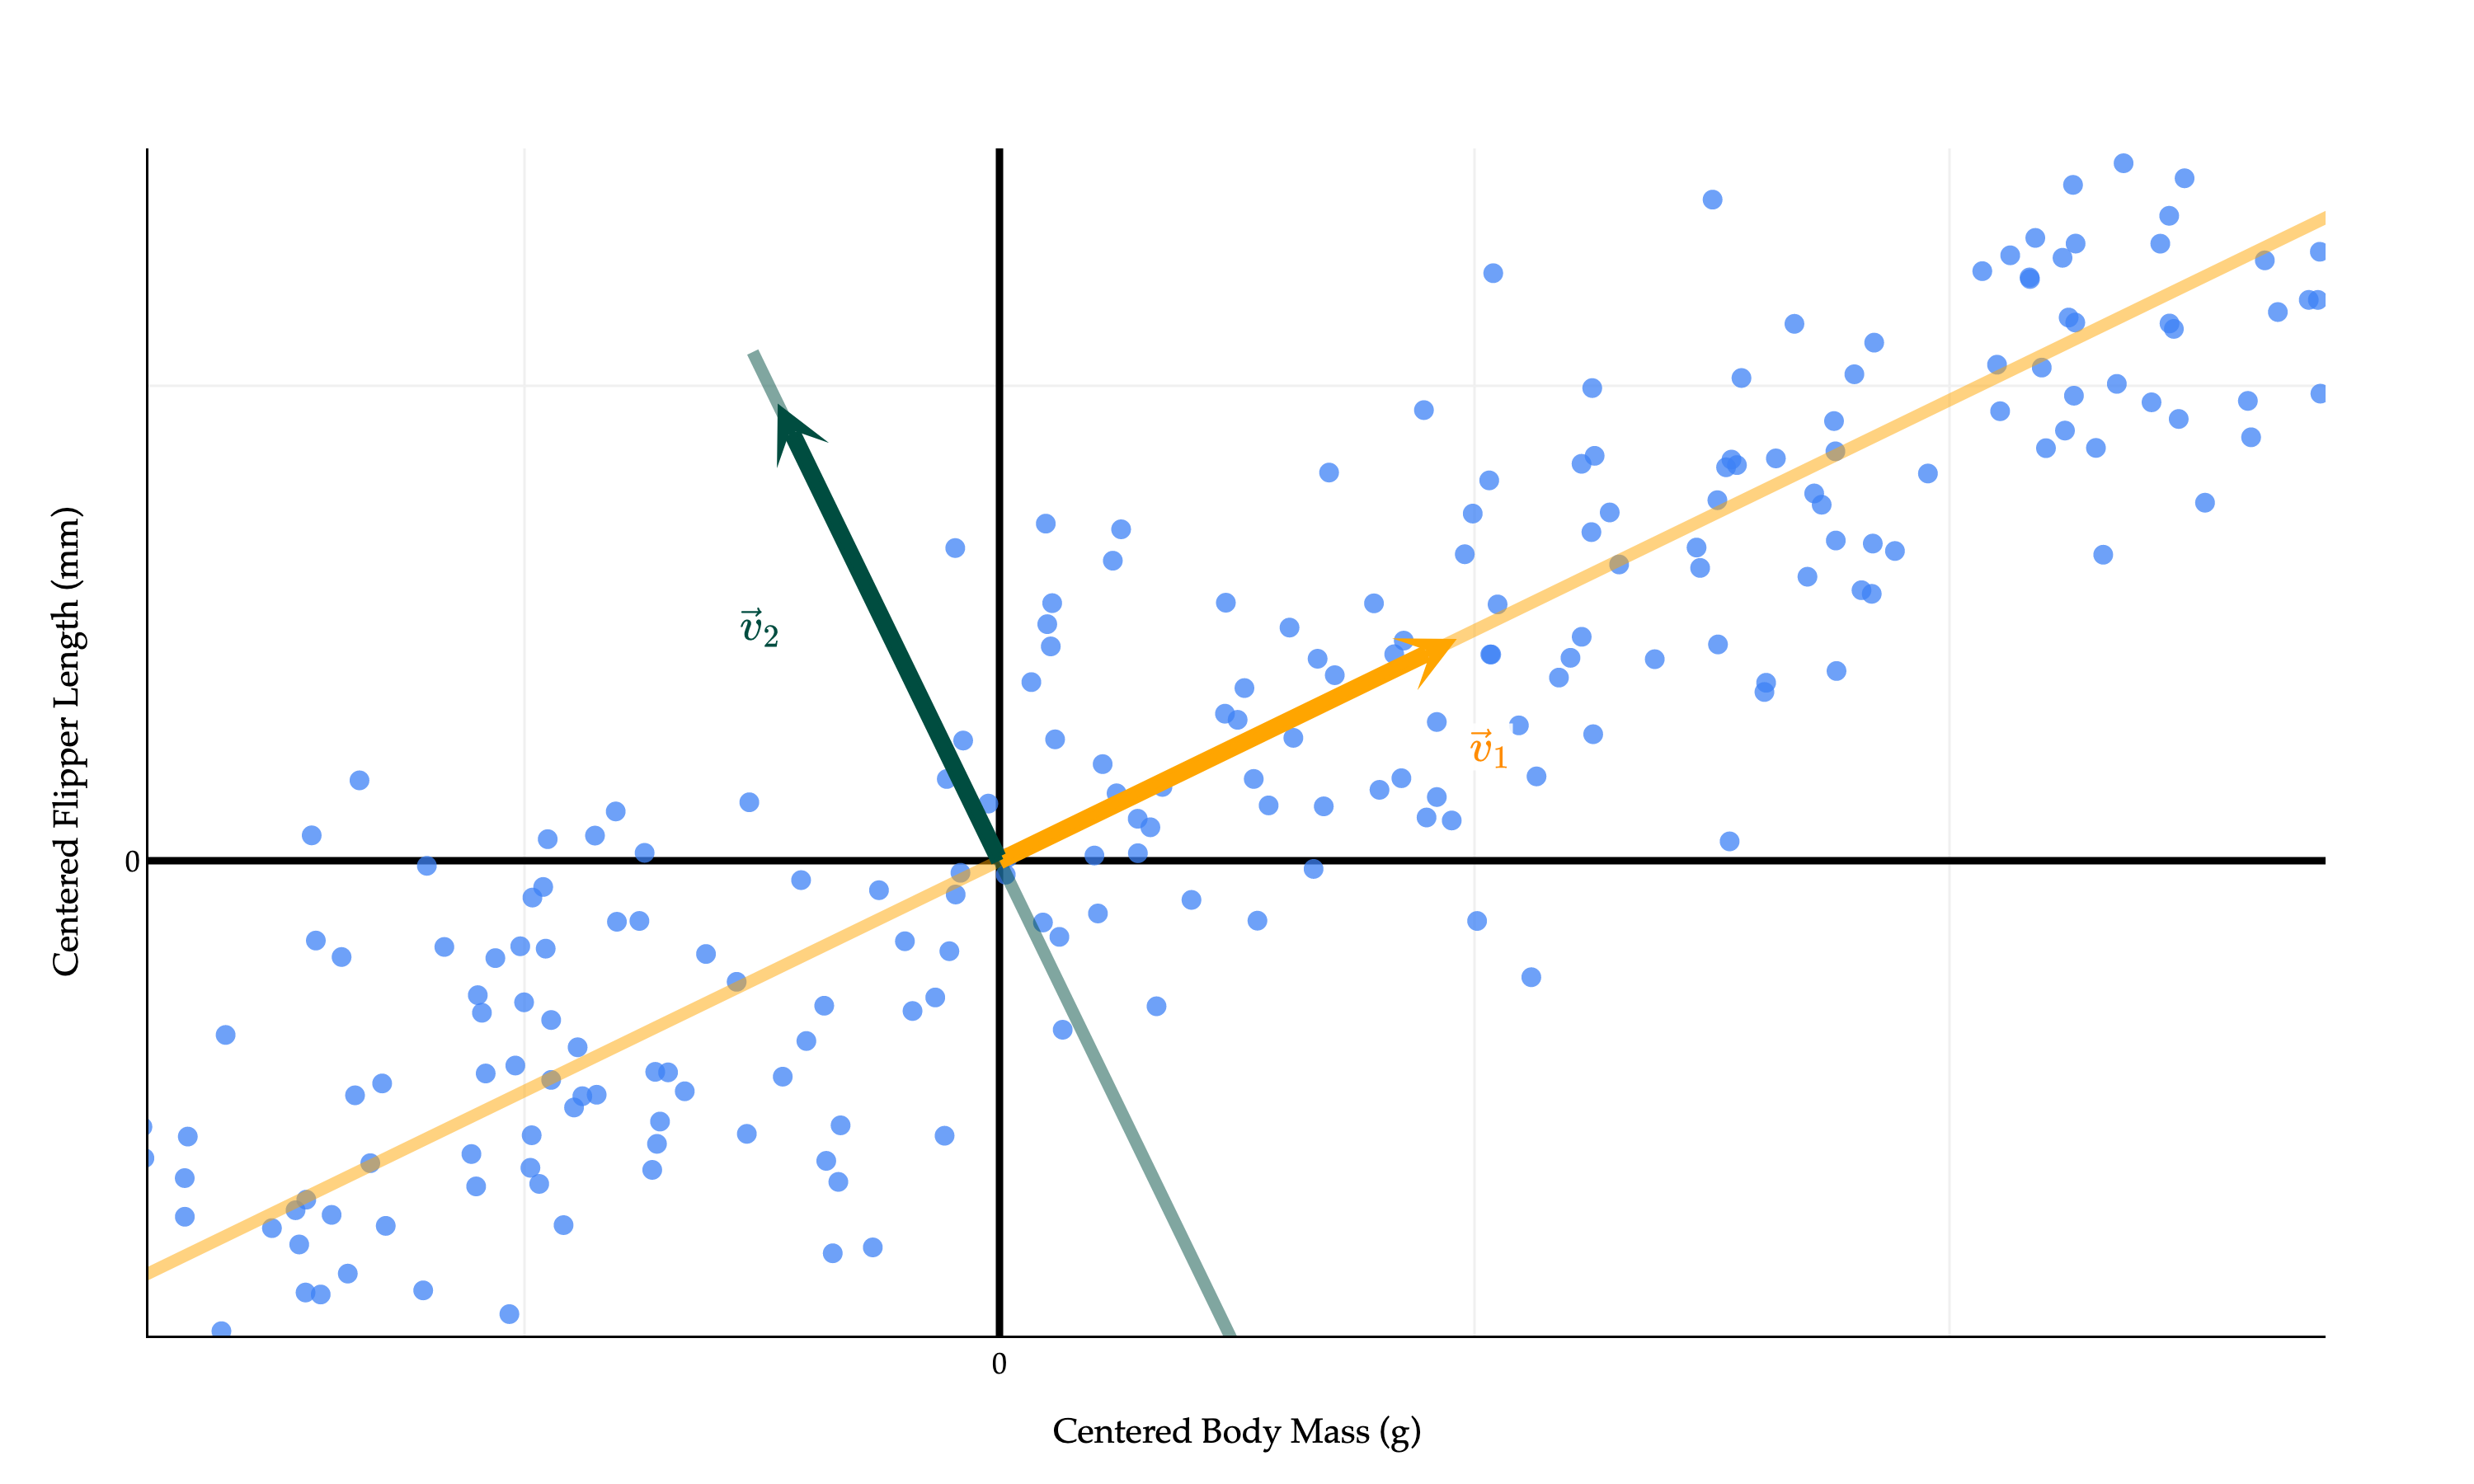

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Use the same synthetic data as above, so the aspect is "fair"
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# Standardize both columns to mean=0, std=1 for correct orthogonal aspect
df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect (as in original)

# Get principal directions using SVD/PCA
U, S, Vt = np.linalg.svd(X, full_matrices=False)
direction1 = Vt[0]
direction1 = direction1 / np.linalg.norm(direction1)

direction2 = Vt[1]
direction2 = direction2 / np.linalg.norm(direction2)

# Plot setup with all standardized points (higher opacity)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=X[:,0], y=X[:,1],
    mode='markers',
    marker=dict(color="#3D81F6", size=8, opacity=0.75),
    showlegend=False,
    hoverinfo='skip'
))

# Principal component line v1 (orange)
proj_min1 = X @ direction1
pc1_min, pc1_max = proj_min1.min(), proj_min1.max()
pc1_extend = 0.20 * (pc1_max - pc1_min)
line_range1 = np.array([pc1_min - pc1_extend, pc1_max + pc1_extend])
line_pts1 = np.outer(line_range1, direction1)

fig.add_trace(go.Scatter(
    x=line_pts1[:,0], y=line_pts1[:,1],
    mode='lines',
    line=dict(color="orange", width=5, dash='solid'),
    opacity=0.5,
    name="Principal Component 1"
))

# Principal component line v2 (#004d40)
proj_min2 = X @ direction2
pc2_min, pc2_max = proj_min2.min(), proj_min2.max()
pc2_extend = 0.20 * (pc2_max - pc2_min)
line_range2 = np.array([pc2_min - pc2_extend, pc2_max + pc2_extend])
line_pts2 = np.outer(line_range2, direction2)

fig.add_trace(go.Scatter(
    x=line_pts2[:,0], y=line_pts2[:,1],
    mode='lines',
    line=dict(color="#004d40", width=5, dash='solid'),
    opacity=0.5,
    name="Principal Component 2"
))

# Draw unit vector v1 centered at (0, 0)
unit_length = 1
vec1_start = np.array([0.0, 0.0])
vec1_end = -direction1 * unit_length

fig.add_trace(go.Scatter(
    x=[vec1_start[0], vec1_end[0]],
    y=[vec1_start[1], vec1_end[1]],
    mode="lines",
    line=dict(color="orange", width=7),
    marker=dict(color="orange", size=[0, 24]), # marker at tip
    showlegend=False
))

# Draw unit vector v2 centered at (0, 0)
vec2_start = np.array([0.0, 0.0])
vec2_end = -direction2 * unit_length

fig.add_trace(go.Scatter(
    x=[vec2_start[0], vec2_end[0]],
    y=[vec2_start[1], vec2_end[1]],
    mode="lines",
    line=dict(color="#004d40", width=7),
    marker=dict(color="#004d40", size=[0, 24]), # marker at tip
    showlegend=False
))

# Add arrowhead for v1
fig.add_annotation(
    x=vec1_end[0]-0.07*direction1[0],
    y=vec1_end[1]-0.07*direction1[1],
    ax=vec1_start[0],
    ay=vec1_start[1],
    xref="x", yref="y", axref="x", ayref="y",
    text="",
    arrowhead=3,
    arrowsize=1.3,
    arrowwidth=3,
    arrowcolor="orange",
    standoff=0,
    opacity=1,
    showarrow=True
)

# Add arrowhead for v2
fig.add_annotation(
    x=vec2_end[0]-0.07*direction2[0],
    y=vec2_end[1]-0.07*direction2[1],
    ax=vec2_start[0],
    ay=vec2_start[1],
    xref="x", yref="y", axref="x", ayref="y",
    text="",
    arrowhead=3,
    arrowsize=1.3,
    arrowwidth=3,
    arrowcolor="#004d40",
    standoff=0,
    opacity=1,
    showarrow=True
)

# Annotate the vector with label \vec v_1 (orange)
label_offset = 0.15
fig.add_annotation(
    x=vec1_end[0] + label_offset * direction1[0] * (-1),
    y=vec1_end[1] + 3 * label_offset * direction1[1],
    text=r"$\vec{v}_1$",
    showarrow=False,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        size=38,
        color='darkorange'
    ),
    bgcolor="rgba(255,255,255,0.88)",
    opacity=1
)

# Annotate the vector with label \vec v_2 (#004d40)
fig.add_annotation(
    x=vec2_end[0] + label_offset * direction2[0] * (-1),
    y=vec2_end[1] + 3 * label_offset * direction2[1],
    text=r"$\vec{v}_2$",
    showarrow=False,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        size=38,
        color='#004d40'
    ),
    bgcolor="rgba(255,255,255,0.9)",
    opacity=1
)

# Aspect ratio 1:1 to make orthogonality look correct
margin_x = 0.2 * (X[:,0].max() - X[:,0].min())
margin_y = 0.2 * (X[:,1].max() - X[:,1].min())
fig.update_xaxes(
    title='Standardized Body Mass',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[X[:,0].min()-margin_x, X[:,0].max()+margin_x],
    scaleanchor='y',  # lock aspect
    scaleratio=1
)
fig.update_yaxes(
    title='Standardized Flipper Length',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    zeroline=True,
    zerolinewidth=3,
    zerolinecolor="black",
    range=[X[:,1].min()-margin_y, X[:,1].max()+margin_y]
)

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=1000,
    height=600,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    xaxis_range=[-1, 2],
    yaxis_range=[-1, 1.5],
    xaxis=dict(
        title='Centered Body Mass (g)',
        tickvals=[-3, -2, -1, 0, 1, 2],
        ticktext=['', '', '', 0, '', '']
    ),
    yaxis=dict(
        title='Centered Flipper Length (mm)',
        tickvals=[-2, -1, 0, 1, 1.5],
        ticktext=['', '', 0, '', '']
    )
)
fig.show(renderer='png', scale=3)

Why is $\vec v_2$ orthogonal to $\vec v_1$? They are both eigenvectors of $\tilde X^T \tilde X$ corresponding to different eigenvalues, so they must be orthogonal, thanks to the spectral theorem (which applies because $\tilde X^T \tilde X$ is symmetric). Remember that while any vector on the line spanned by $\vec v_2$ is also an eigenvector of $\tilde X^T \tilde X$ corresponding to the second largest eigenvalue, we pick the specific $\vec v_2$ that is a unit vector.

$\vec v_2$ and $\vec v_1$ being orthogonal means that $\tilde X \vec v_2$ and $\tilde X \vec v_1$ are orthogonal, too. But **because** the columns of $\tilde X$ are mean centered, we can show that this implies that the correlation between $\text{PC}_1$ and $\text{PC}_2$ is $0$. I'll save the algebra for now, but see if you can work this out yourself. You've done similar proofs in homeworks already.

### The SVD Returns

The moment I said that $\vec v_1$ is an eigenvector of $\tilde X^T \tilde X$, something should have been ringing in your head: $\vec v_1$ is a **singular vector** of $\tilde X$! Recall, if

$$\tilde X = \underbrace{\begin{bmatrix} {\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} & {\color{#aaaaaa} |} & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} |} \\ {\color{#3d81f6} \vec u_1} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} \vec u_r} & {\color{#aaaaaa} \vec u_{r+1}} & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} \vec u_n} \\ {\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} & {\color{#aaaaaa} |} & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} |} \end{bmatrix}}_{U}
\underbrace{\begin{bmatrix}
{\color{orange} \sigma_1} & {\color{#aaaaaa} } & {\color{#aaaaaa} } & {\color{#aaaaaa} 0}          & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0} \\
{\color{#aaaaaa} } & {\color{orange} \ddots} & {\color{#aaaaaa} } & {\color{#aaaaaa} \vdots}      & {\color{#aaaaaa} } & {\color{#aaaaaa} \vdots} \\
{\color{#aaaaaa} } & {\color{#aaaaaa} } & {\color{orange} \sigma_r} & {\color{#aaaaaa} 0}          & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0} \\[6pt]
{\color{#aaaaaa} 0}        & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0}       & {\color{#aaaaaa} 0}          & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0} \\
{\color{#aaaaaa} \vdots}   & {\color{#aaaaaa} } & {\color{#aaaaaa} \vdots}   & {\color{#aaaaaa} \vdots}     & {\color{#aaaaaa} } & {\color{#aaaaaa} \vdots} \\
{\color{#aaaaaa} 0}        & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0}       & {\color{#aaaaaa} 0}          & {\color{#aaaaaa} \cdots} & {\color{#aaaaaa} 0}
\end{bmatrix}}_{\Sigma}
\underbrace{\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}} \\ \\
{\color{#aaaaaa} \text{---} \:\: \vec v_{r+1}^T \:\: \text{---}} \\
{\color{#aaaaaa} \vdots} \\
{\color{#aaaaaa} \text{---} \:\: \vec v_d^T \:\: \text{---}} \\
\end{bmatrix}}_{V^T}
$$

is the singular value decomposition of $\tilde X$, then the columns of $V$ are the eigenvectors of $\tilde X^T \tilde X$, all of which are orthogonal to each other and have unit length.

We arranged the components in the singular value decomposition in decreasing order of singular values of $\tilde X$, which are the square roots of the eigenvalues of $\tilde X^T \tilde X$.

$$\sigma_i = \sqrt{\lambda_i}, \quad \text{where } \lambda_i \text{ is the } i\text{-th largest eigenvalue of } \tilde X^T \tilde X$$

So,
- the first column of $V$ is $\vec v_1$, the "best direction" to project the data onto, 
- the second column of $V$ is $\vec v_2$, the "second-best direction" to project the data onto,
- the third column of $V$ is $\vec v_3$, the "third-best direction" to project the data onto,
- and so on.

:::{attention} Finding Principal Components
In general, principal component $j$ comes from multiplying $\tilde X$ by the $j$-th column of $V$, where $\tilde X = U \Sigma V^T$ is the SVD of $\tilde X$, and $\tilde X$ is the mean-centered version of $X$.

$$\text{PC}_j = \tilde X \vec v_j$$

To find all principal components at once, all we need to do is multiply $\tilde X$ by the entire matrix $V$. The resulting matrix is sometimes called the principal component matrix.

$$\tilde X V = \begin{bmatrix} | & | & & | \\ \text{PC}_1 & \text{PC}_2 & \cdots & \text{PC}_d \\ | & | & & | \end{bmatrix}$$

Equivalently, $\tilde X V = U \Sigma$.
:::

Let's put this in context with a few examples.

### Example: From $\mathbb{R}^2$ to $\mathbb{R}^2$

Let's start with the 2-dimensional dataset of flipper length vs. body mass from the `penguins` dataset.

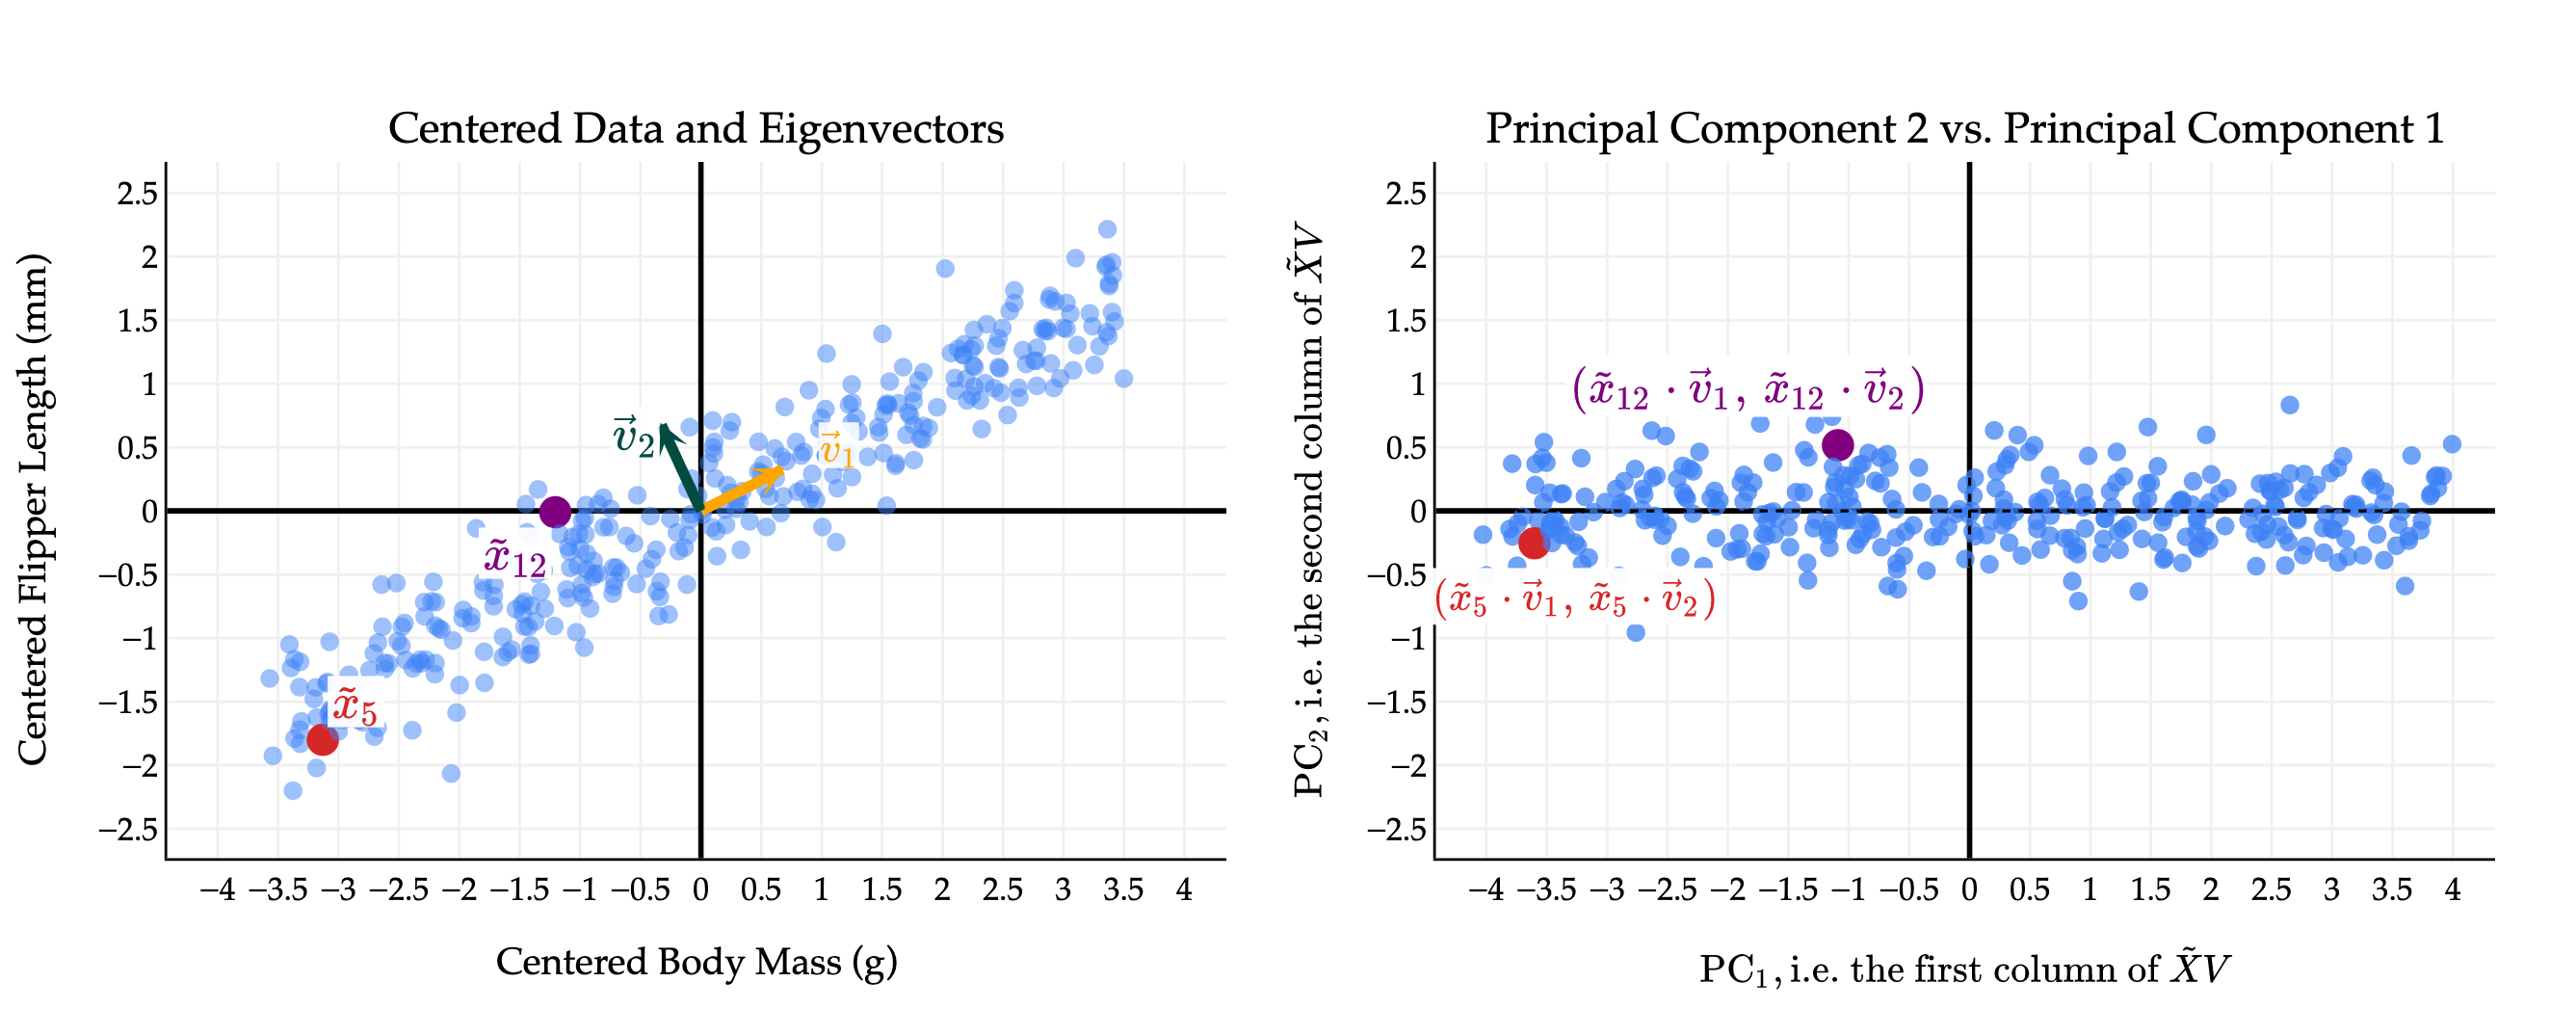

In [6]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Use the same synthetic data as above, so the aspect is "fair"
np.random.seed(102)
num_points = 340
body_mass_g = np.random.uniform(2700, 6300, num_points)
m_true = 0.015
c_true = 120
noise = np.random.normal(0, 5, num_points)
flipper_length_mm = m_true * body_mass_g + c_true + noise

df = pd.DataFrame({
    'body_mass_g': body_mass_g,
    'flipper_length_mm': flipper_length_mm
})

# Standardize both columns to mean=0, std=1 for correct orthogonal aspect
df['body_mass_std'] = (df['body_mass_g'] - df['body_mass_g'].mean()) / df['body_mass_g'].std()
df['flipper_length_std'] = (df['flipper_length_mm'] - df['flipper_length_mm'].mean()) / df['flipper_length_mm'].std()
X = df[['body_mass_std', 'flipper_length_std']].values
X[:, 0] *= 2 # Scale x-axis for visual effect (as in original)

# Center the data
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

# SVD/PCA for centered data
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
U = -U
Vt = -Vt
direction1 = Vt[0] / np.linalg.norm(Vt[0])
direction2 = Vt[1] / np.linalg.norm(Vt[1])

# Project data into principal components
PCs = X_centered @ Vt.T        # (n,2): each row is [PC1, PC2]
PC1 = PCs[:, 0]
PC2 = PCs[:, 1]
n = len(PC1)

# Compute eigenvalues for drawing
eigvals = S ** 2

# For drawing eigvec lines: scale as in file_context_0
vec_scale = 0.7 * np.max(np.abs(X_centered))
v1_pts = np.vstack([-direction1, direction1]) * vec_scale
v2_pts = np.vstack([-direction2, direction2]) * vec_scale

# --- Highlight points: i5 and (NEW) i12 ---
i5 = 136   # 5th entry (Python-0-based)
x5 = X_centered[i5]
x5_bm, x5_fl = x5
pc_x5 = PCs[i5]      # [PC1, PC2] for the chosen point

x12 = 15
x12_arr = X_centered[x12]
x12_bm, x12_fl = x12_arr
pc_x12 = PCs[x12]    # [PC1, PC2] for the orange point

# For aspect/axes ranges (used on both plots)
margin_bm = 0.12 * (X_centered[:, 0].max() - X_centered[:, 0].min())
margin_fl = 0.12 * (X_centered[:, 1].max() - X_centered[:, 1].min())
xr = X_centered[:, 0].min() - margin_bm, X_centered[:, 0].max() + margin_bm
yr = X_centered[:, 1].min() - margin_fl, X_centered[:, 1].max() + margin_fl

# Try to zoom out the PCA plot to match left's ranges and step sizes (rather than local PC-only margin)
xr_pc = xr
yr_pc = yr

# ----- Setup side-by-side plots -----
fig = make_subplots(
    cols=2,
    subplot_titles=(
        "Centered Data and Eigenvectors", 
        "Principal Component 2 vs. Principal Component 1"
    ),
    horizontal_spacing=0.09
)

new_pt_color = "purple"

# -- Left: All centered data points, blue except two highlights --
marker_colors = np.full(X_centered.shape[0], "#3D81F6")
marker_colors[i5] = "#d62728"
marker_colors[x12] = new_pt_color

fig.add_trace(
    go.Scatter(
        x=X_centered[:, 0],
        y=X_centered[:, 1],
        mode="markers",
        showlegend=False,
        marker=dict(
            color=marker_colors,
            size=[10 if i == i5 or i == x12 else 7 for i in range(len(marker_colors))],
            line=dict(
                width=[2 if i == i5 or i == x12 else 0 for i in range(len(marker_colors))],
                color=["#d62728" if i==i5 else (new_pt_color if i==x12 else "#3D81F6") for i in range(len(marker_colors))]
            ),
            opacity=[1 if i == i5 or i == x12 else 0.5 for i in range(len(marker_colors))]
        ),
        name="Centered Data"
    ),
    row=1, col=1
)

# Annotate the picked point as \tilde x_5 (red)
fig.add_annotation(
    x=x5_bm, y=x5_fl,
    xshift=12, yshift=14,
    text=r"$\tilde{x}_5$",
    font=dict(size=22, color="#d62728", family="Palatino Linotype, Palatino, serif"),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.95)",
    borderpad=2,
    row=1, col=1
)

# Annotate the new orange point as \tilde x_{12}
fig.add_annotation(
    x=x12_bm, y=x12_fl,
    xshift=-15, yshift=-15,
    text=r"$\tilde{x}_{12}$",
    font=dict(size=22, color=new_pt_color, family="Palatino Linotype, Palatino, serif"),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.95)",
    borderpad=2,
    row=1, col=1
)

# --- Draw PCA eigenvector arrows (short, thin) ---
thin_vector_length = 0.21 * np.max(np.abs(X_centered))  # much shorter
tiny_width = 4  # much thinner

vec1_start = np.array([0.0, 0.0])
vec1_end = direction1 * thin_vector_length
vec2_start = np.array([0.0, 0.0])
vec2_end = direction2 * thin_vector_length

# Arrow for v1 (thin & short)
fig.add_trace(go.Scatter(
    x=[vec1_start[0], vec1_end[0]],
    y=[vec1_start[1], vec1_end[1]],
    mode="lines",
    line=dict(color="orange", width=tiny_width),
    marker=dict(color="orange", size=[0, 14]),
    showlegend=False
), row=1, col=1)
fig.add_annotation(
    x=vec1_end[0]+0.02*direction1[0],
    y=vec1_end[1]+0.02*direction1[1],
    ax=vec1_start[0],
    ay=vec1_start[1],
    xref="x", yref="y", axref="x", ayref="y",
    text="",
    arrowhead=3,
    arrowsize=1.75,
    arrowwidth=1.1,
    arrowcolor="orange",
    standoff=0,
    opacity=1,
    row=1, col=1,
    showarrow=True
)
# Annotate \vec v_1 in orange
fig.add_annotation(
    x=vec1_end[0],
    y=vec1_end[1],
    xshift=-29 if direction1[0] < 0 else 21,
    yshift=9,
    text=r"$\vec{v}_1$",
    font=dict(size=15, color="orange", family="Palatino Linotype, Palatino, serif"),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.88)",
    borderpad=1,
    row=1, col=1
)

# Arrow for v2 (thin & short)
fig.add_trace(go.Scatter(
    x=[vec2_start[0], vec2_end[0]],
    y=[vec2_start[1], vec2_end[1]],
    mode="lines",
    line=dict(color="#004d40", width=tiny_width),
    marker=dict(color="#004d40", size=[0, 14]),
    showlegend=False
), row=1, col=1)
fig.add_annotation(
    x=vec2_end[0]+0.02*direction2[0],
    y=vec2_end[1]+0.02*direction2[1],
    ax=vec2_start[0],
    ay=vec2_start[1],
    xref="x", yref="y", axref="x", ayref="y",
    text="",
    arrowhead=3,
    arrowsize=1.75,
    arrowwidth=1.1,
    arrowcolor="#004d40",
    standoff=0,
    opacity=1,
    row=1, col=1,
    showarrow=True
)
# Annotate \vec v_2 in dark green
fig.add_annotation(
    x=vec2_end[0],
    y=vec2_end[1],
    xshift=-10,#-37 if direction2[0] < 0 else 20,
    yshift=-2,
    text=r"$\vec{v}_2$",
    font=dict(size=22, color="#004d40", family="Palatino Linotype, Palatino, serif"),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.89)",
    borderpad=1,
    row=1, col=1
)

# --- PC Plot (right): scatter all points in PC1/PC2, highlight PC of x5 and x12 ---
PC_marker_colors = np.full(n, "#3D81F6")
PC_marker_colors[i5] = "#d62728"
PC_marker_colors[x12] = new_pt_color

fig.add_trace(
    go.Scatter(
        x=PC1,
        y=PC2,
        mode="markers",
        marker=dict(
            color=PC_marker_colors,
            size=[10 if i==i5 or i==x12 else 7 for i in range(n)],
            line=dict(
                width=[2 if i==i5 or i==x12 else 0 for i in range(n)],
                color=[
                    "#d62728" if i==i5 else
                    (new_pt_color if i==x12 else "#3D81F6")
                    for i in range(n)
                ]
            ),
            opacity=[1 if i==i5 or i==x12 else 0.74 for i in range(n)],
        ),
        showlegend=False,
        name="PC Scores"
    ),
    row=1, col=2
)

# Draw axes for PC1/PC2 (right) -- match scale of left plot
fig.add_trace(
    go.Scatter(
        x=[xr_pc[0], xr_pc[1]], y=[0, 0],
        mode="lines",
        line=dict(color="black", width=1.1, dash="dot"),
        showlegend=False,
        hoverinfo="skip"
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        x=[0, 0], y=[yr_pc[0], yr_pc[1]],
        mode="lines",
        line=dict(color="black", width=1.1, dash="dot"),
        showlegend=False,
        hoverinfo="skip"
    ),
    row=1, col=2
)

# Annotate highlighted PC as (\tilde x_5 \cdot v_1, \tilde x_5 \cdot v_2) (red)
fig.add_annotation(
    x=pc_x5[0], y=pc_x5[1],
    xshift=15, yshift=-20,
    text=r"$(\tilde{x}_5 \cdot \vec{v}_1,\, \tilde{x}_5 \cdot \vec{v}_2)$",
    font=dict(size=15, family="Palatino Linotype, Palatino, serif", color="#d62728"),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.96)",
    row=1, col=2,
    borderpad=2,
)

# Annotate orange point in PC space
fig.add_annotation(
    x=pc_x12[0], y=pc_x12[1],
    xshift=-34, yshift=22,
    text=r"$(\tilde{x}_{12} \cdot \vec{v}_1,\, \tilde{x}_{12} \cdot \vec{v}_2)$",
    font=dict(size=17, family="Palatino Linotype, Palatino, serif", color=new_pt_color),
    showarrow=False,
    bgcolor="rgba(255,255,255,0.98)",
    row=1, col=2,
    borderpad=2,
)

# --- Ensure axis ranges and step size are identical on both ---
fig.update_xaxes(
    title="Centered Body Mass (g)", row=1, col=1,
    gridcolor="#f0f0f0", showline=True, linecolor="black",
    linewidth=1, zeroline=True, zerolinewidth=2, zerolinecolor="black",
    range=xr,
    dtick=0.5,
)
fig.update_yaxes(
    title="Centered Flipper Length (mm)", row=1, col=1,
    gridcolor="#f0f0f0", showline=True, linecolor="black",
    linewidth=1, zeroline=True, zerolinewidth=2, zerolinecolor="black",
    range=yr,
    dtick=0.5,
)
fig.update_xaxes(
    title=r"$\text{PC}_1, \text{i.e. the first column of } \tilde X V$", row=1, col=2,
    gridcolor="#f0f0f0", showline=True, linecolor="black",
    linewidth=1, zeroline=True, zerolinewidth=2, zerolinecolor="black",
    range=xr_pc,
    dtick=0.5,
)
fig.update_yaxes(
    title=r"$\text{PC}_2, \text{i.e. the second column of } \tilde X V$", row=1, col=2,
    gridcolor="#f0f0f0", showline=True, linecolor="black",
    linewidth=1, zeroline=True, zerolinewidth=2, zerolinecolor="black",
    range=yr_pc,
    dtick=0.5,
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    margin=dict(l=30, r=30, t=60, b=40),
    width=955,
    height=374,
    showlegend=False,
)

fig.show(renderer="png", scale=2.8)


The first thing you should notice is that while the original data points seem to have some positive correlation, **the principal components are uncorrelated**! This is a good thing; it's what we wanted as a design goal. In effect, by converting from the original features to principal components, we've rotated the data to remove the correlation between the features.

I have picked two points to highlight, points 5 and 12 in the original data. The coloring in <span style="color: #d62728; font-weight: bold;">red</span> and <span style="color: purple; font-weight: bold;">purple</span> is meant to show you how original (centered) data points translate to points in the principal component space.

Notice the scale of the data: $\text{PC}_1$ axis is much longer than the $\text{PC}_2$ axis, since the first principal component captures much more variance than the second. We will make this notion - of the proportion of variance captured by each principal component - more precise soon.

(You'll notice that the body mass and flipper length values on the left are much smaller than in the original datasets; in the original dataset, the body mass values were in the thousands, which distorted the scale of the plot and made it hard to see that the two eigenvectors are indeed orthogonal.)

### Example: Starting from $\mathbb{R}^3$

The real power of PCA reveals itself when we start with high-dimensional data. Suppose we start with three of the features in the `penguins` dataset: `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g` - and want to reduce the dimensionality of the data to 1 or 2. Points are colored by their `species`.

In [7]:
X_three_features = penguins[['bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna().copy()

In [8]:
import plotly.express as px

df_3d = penguins[['bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna().copy()
# df_3d = df_3d - df_3d.mean(axis=0)

species_color_map = {
    'Adelie': '#ff7400',
    'Chinstrap': '#c45bcc',
    'Gentoo': '#077575'
}

fig = px.scatter_3d(
    df_3d,
    x="bill_depth_mm",
    y="flipper_length_mm",
    z="body_mass_g",
    # color=None,
    opacity=0.7,
    title="",
    labels={
        "bill_depth_mm": "Bill Depth (mm)",
        "flipper_length_mm": "Flipper Length (mm)",
        "body_mass_g": "Body Mass (g)"
    },
    color=penguins["species"],
    color_discrete_map=species_color_map
)
# Get current axis ranges for later use with grid lines
x_range = [df_3d["bill_depth_mm"].min(), df_3d["bill_depth_mm"].max()]
y_range = [df_3d["flipper_length_mm"].min(), df_3d["flipper_length_mm"].max()]
z_range = [df_3d["body_mass_g"].min(), df_3d["body_mass_g"].max()]

# # Add gridlines for x=0, y=0, z=0 in black
# fig.add_trace({
#     "type": "scatter3d",
#     "x": [0, 0],
#     "y": y_range,
#     "z": [0, 0],
#     "mode": "lines",
#     "line": {"color": "black", "width": 4},
#     "showlegend": False,
#     "hoverinfo": "skip"
# })
# fig.add_trace({
#     "type": "scatter3d",
#     "x": x_range,
#     "y": [0, 0],
#     "z": [0, 0],
#     "mode": "lines",
#     "line": {"color": "black", "width": 4},
#     "showlegend": False,
#     "hoverinfo": "skip"
# })
# fig.add_trace({
#     "type": "scatter3d",
#     "x": [0, 0],
#     "y": [0, 0],
#     "z": z_range,
#     "mode": "lines",
#     "line": {"color": "black", "width": 4},
#     "showlegend": False,
#     "hoverinfo": "skip"
# })

fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    scene=dict(
        xaxis_title="Bill Depth (mm)",
        yaxis_title="Flipper Length (mm)",
        zaxis_title="Body Mass (g)",
        bgcolor="white",
        xaxis=dict(
            gridcolor="#f0f0f0",
            showbackground=True,
            backgroundcolor="white",
            showline=True,
            linecolor="black",
            title_font=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            ),
            tickfont=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            )
        ),
        yaxis=dict(
            gridcolor="#f0f0f0",
            showbackground=True,
            backgroundcolor="white",
            showline=True,
            linecolor="black",
            title_font=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            ),
            tickfont=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            )
        ),
        zaxis=dict(
            gridcolor="#f0f0f0",
            showbackground=True,
            backgroundcolor="white",
            showline=True,
            linecolor="black",
            title_font=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            ),
            tickfont=dict(
                family="Palatino Linotype, Palatino, serif",
                color="black"
            )
        ),
    ),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    height=500,
    width=900
)
fig.show()

Observe that penguins of the same species tend to be clustered together. This, alone, has nothing to do with PCA: we happen to have this information, so I've included it in the plot.

If $X$ is the $333 \times 3$ matrix of three features, and $\tilde X$ is the mean-centered version, the best directions in which to project the data are the columns of $V$ in $\tilde X = U \Sigma V^T$.

In [9]:
X_three_features

,bill_depth_mm,flipper_length_mm,body_mass_g
0,18.7,181.0,3750.0
1,17.4,186.0,3800.0
2,18.0,195.0,3250.0
4,19.3,193.0,3450.0
5,20.6,190.0,3650.0
...,...,...,...
338,13.7,214.0,4925.0
340,14.3,215.0,4850.0
341,15.7,222.0,5750.0
342,14.8,212.0,5200.0


In [10]:
X_three_features.mean()

bill_depth_mm          17.164865
flipper_length_mm     200.966967
body_mass_g          4207.057057
dtype: float64

In [11]:
# This is the mean-centered version of X_three_features!
X_three_features - X_three_features.mean()

,bill_depth_mm,flipper_length_mm,body_mass_g
0,1.535135,-19.966967,-457.057057
1,0.235135,-14.966967,-407.057057
2,0.835135,-5.966967,-957.057057
4,2.135135,-7.966967,-757.057057
5,3.435135,-10.966967,-557.057057
...,...,...,...
338,-3.464865,13.033033,717.942943
340,-2.864865,14.033033,642.942943
341,-1.464865,21.033033,1542.942943
342,-2.364865,11.033033,992.942943


In [12]:
X_three_features_centered = X_three_features - X_three_features.mean()
u, s, vt = np.linalg.svd(X_three_features_centered)

Now, the rows of $V^T$ (`vt`), which are the columns of $V$ (`vt.T`), contain the best directions.

In [13]:
vt

array([[-1.15433983e-03,  1.51946036e-02,  9.99883889e-01],
       [ 1.02947493e-01, -9.94570148e-01,  1.52327042e-02],
       [ 9.94686122e-01,  1.02953123e-01, -4.16174416e-04]])

It's important to remember that these "best directions" are nothing more than linear combinations of the original features. Since the first row of $V^T$ is $\begin{bmatrix} -0.00115 & 0.01519 & 0.99988 \end{bmatrix}$, the first principal component is

$$\text{PC 1}_i = -0.00115 \cdot \text{bill depth}_i + 0.01519 \cdot \text{flipper length}_i + 0.99988 \cdot \text{body mass}_i$$

while the second is

$$\text{PC 2}_i = 0.10294 \cdot \text{bill depth}_i - 0.99457 \cdot \text{flipper length}_i + 0.01523 \cdot \text{body mass}_i$$

and third is

$$\text{PC 3}_i = 0.99468 \cdot \text{bill depth}_i + 0.10295 \cdot \text{flipper length}_i - 0.00042 \cdot \text{body mass}_i$$

where $i = 1, 2, \ldots, 333$ is the index of the penguin.

To compute all three of these principal components at once, for every penguin, we just need to compute $\tilde X V$.

In [14]:
pcs = X_three_features_centered @ vt.T
pcs

,0,1,2
0,-457.309150,13.054373,-0.338469
1,-407.237482,8.709325,-1.137604
2,-957.037562,-8.558025,0.614682
4,-757.092674,-3.388512,1.618633
5,-557.162981,2.775571,2.519631
...,...,...,...
338,718.061613,-2.382752,-2.403451
340,643.084824,-4.458007,-1.672473
341,1543.085070,2.433563,0.066202
342,992.998024,3.908624,-1.629651


Let's plot the first two principal components: that is, for each of our 333 penguins, we'll plot their value of $\tilde X \vec v_1$ on the $x$-axis and their value of $\tilde X \vec v_2$ on the $y$-axis.

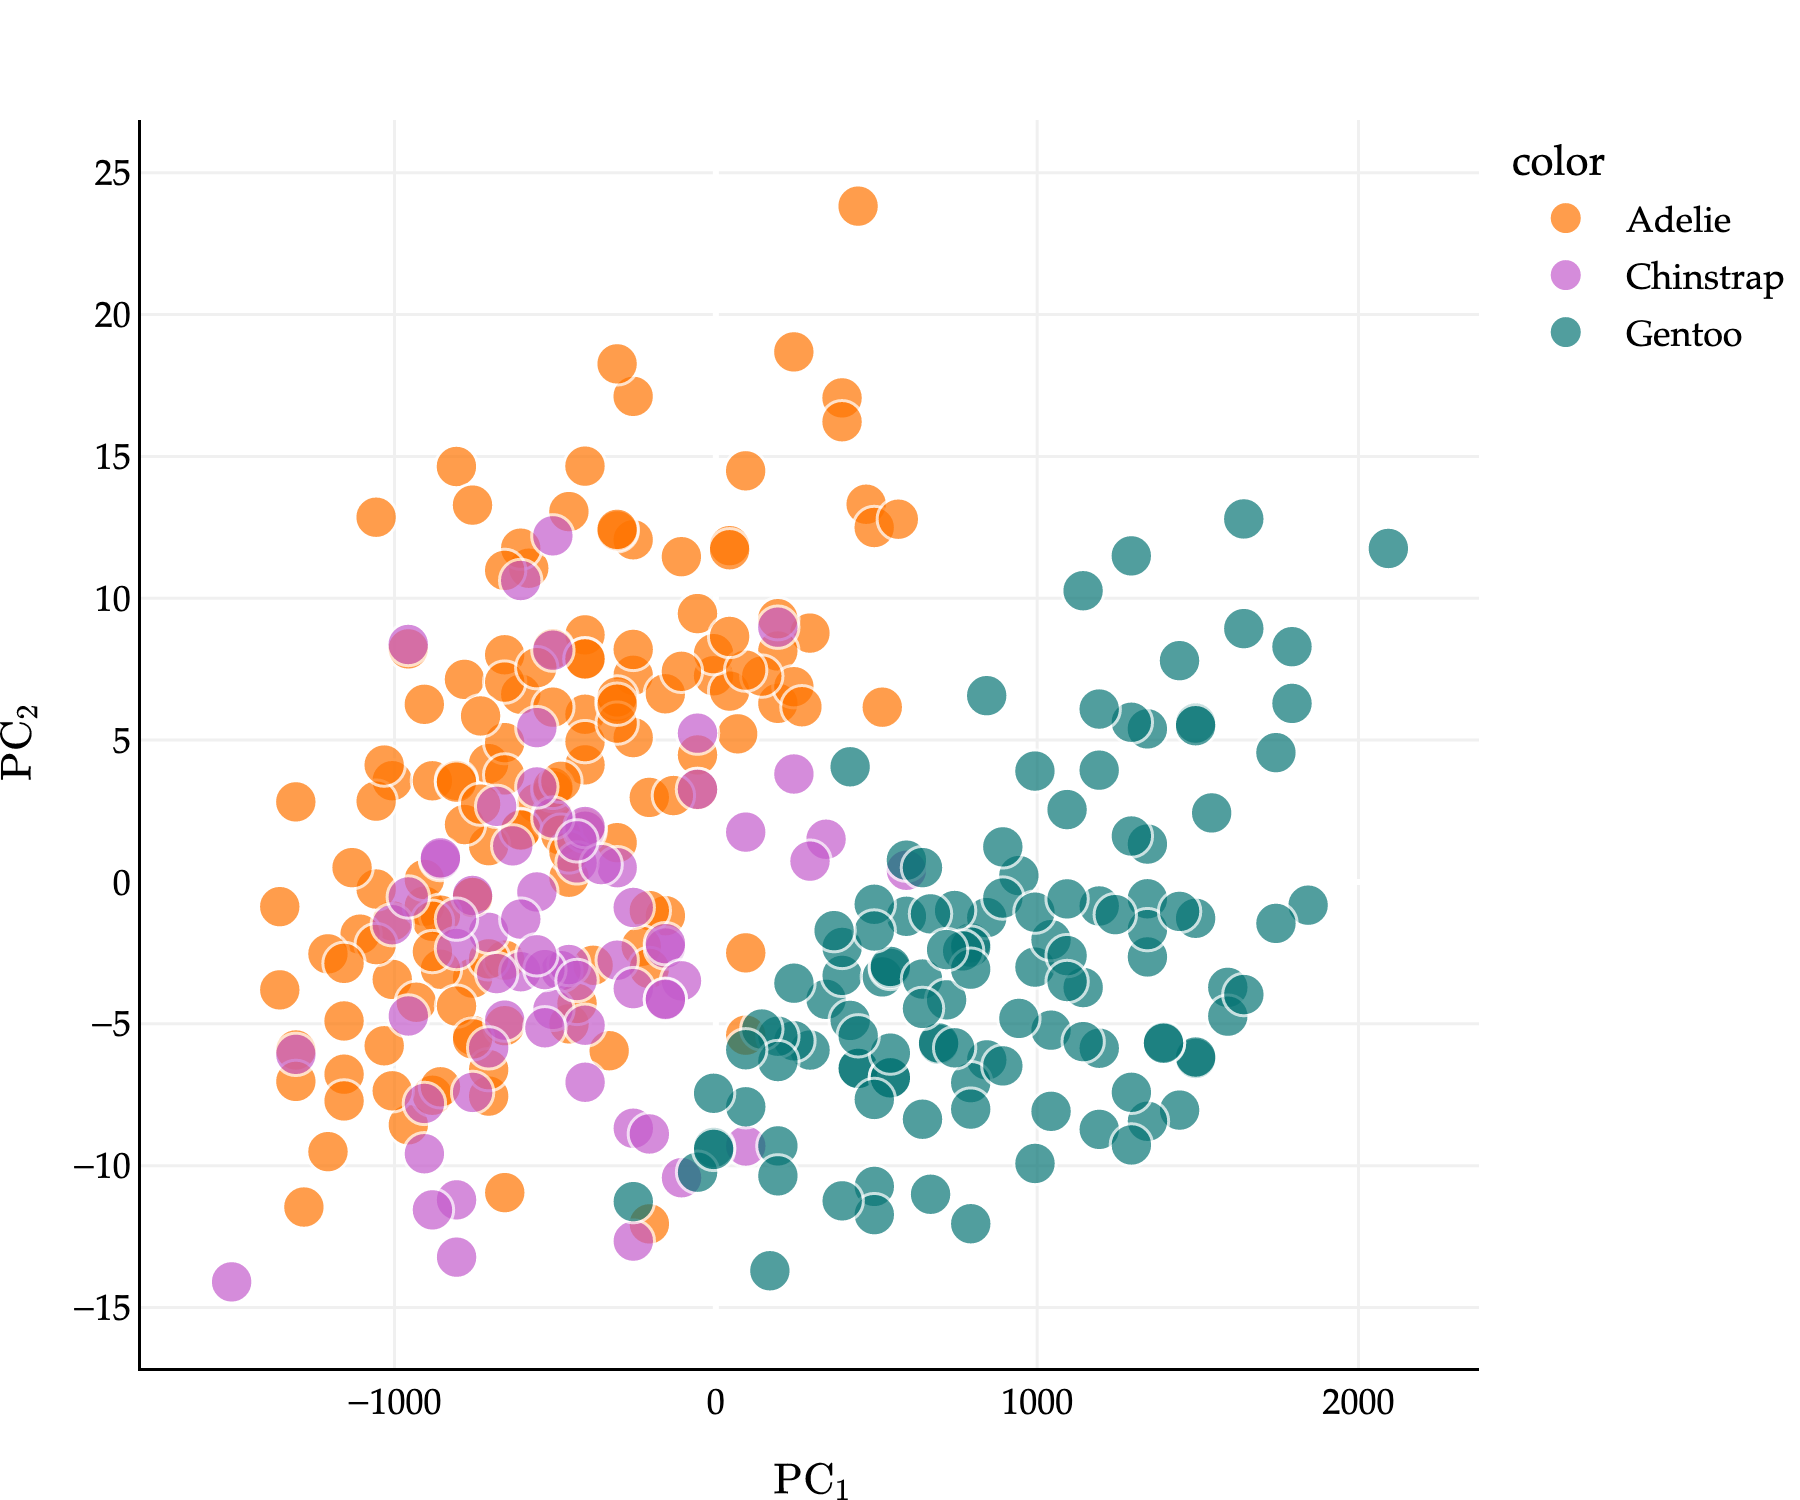

In [15]:
species_color_map = {
    'Adelie': '#ff7400',
    'Chinstrap': '#c45bcc',
    'Gentoo': '#077575'
}

fig = px.scatter(
    pcs,
    x=pcs.columns[0],
    y=pcs.columns[1],
    opacity=0.7,
    # title="First Two Principal Components",
    labels={
        pcs.columns[0]: r"$\text{PC}_1$",
        pcs.columns[1]: r"$\text{PC}_2$"
    },
    size_max=10,
    size=[10] * pcs.shape[0],
    color=penguins["species"],
    color_discrete_map=species_color_map
)
fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    xaxis_title=r"$\text{PC}_1$",
    yaxis_title=r"$\text{PC}_2$",
    plot_bgcolor="white",
    xaxis=dict(
        gridcolor="#f0f0f0",
        showline=True,
        linecolor="black",
        title_font=dict(
            family="Palatino Linotype, Palatino, serif",
            color="black"
        ),
        tickfont=dict(
            family="Palatino Linotype, Palatino, serif",
            color="black"
        )
    ),
    yaxis=dict(
        gridcolor="#f0f0f0",
        showline=True,
        linecolor="black",
        title_font=dict(
            family="Palatino Linotype, Palatino, serif",
            color="black"
        ),
        tickfont=dict(
            family="Palatino Linotype, Palatino, serif",
            color="black"
        )
    ),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    height=500,
    width=600
)

fig.show(renderer="png", scale=3)

This is the best 2-dimensional projection of our 3-dimensional scatter plot. And here's the kicker: **penguins of the same species STILL tend to be clustered together in the principal component space!**

What this tells us is that our technique for taking linear combinations of the original features is good at preserving the important information in the original dataset. We went from writing down 3 numbers per penguin to 2, but it seems that we didn't lose much information per penguin.

What do I mean by "much important information"? Let's make this idea more precise.

---

## Explained Variance

The goal of PCA is to find new features - principal components - that capture as much of the variation in the data as possible, while being uncorrelated with each other.

PCA isn't foolproof: it works better on some datasets than others. If the features we're working with are already uncorrelated, PCA isn't useful. And, even for datasets that are well suited for PCA, we need a systematic way to decide how many principal components to use. So far, we've often used 1 or 2 principal components for the purposes of visualization, but in general, we need a more systematic approach. What if we start with an $n \times 50$ matrix and want to decide how many principal components to compute?

Let's define the **total variance** of an $n \times d$ matrix $X$ as the sum of the variances of the columns of $X$. If $x_i^{(j)}$ is the $i$-th value of the $j$-th feature, and $\mu_j$ is the mean of the $j$-th feature, then the total variance of $X$ is

$$\text{total variance} = \sum_{j = 1}^d \left(\frac{1}{n} \sum_{i = 1}^n (x_i^{(j)} - \mu_j)^2 \right)$$

Let's compute this for `X_three_features`.

In [16]:
X_three_features.var(ddof=0) # The variances of the individual columns of X.

bill_depth_mm             3.866243
flipper_length_mm       195.851762
body_mass_g          646425.423171
dtype: float64

In [17]:
X_three_features.var(ddof=0).sum()

646625.1411755901

So, the total variance of `X_three_features` is approximately 646625.

This is also equal to the **sum** of the variances of the columns of $\tilde XV$, i.e. the sum of the variances of the principal components!

In [18]:
# These three numbers are DIFFERENT than the numbers above,
# but their sum is the same.
(X_three_features_centered @ vt.T).var(ddof=0)

0    646575.552578
1        47.055776
2         2.532822
dtype: float64

In [19]:
(X_three_features_centered @ vt.T).var(ddof=0).sum() # Same sum as before.

646625.1411755901

Why? If we create the same number of principal components as we have original features, we haven't lost any information - we've just written the same data in a different basis. The goal, though, is to pick a number of principal components that is relatively small (smaller than the number of original features), but still captures most of the variance in the data.

Each new principal component - that is, each column of $\tilde X V$ - captures some amount of this total variance. What we'd like to measure is the **proportion** (that is, fraction, or percentage) of the total variance that each principal component captures. The first principal component captures the most variance, since it corresponds to the direction in which the data varies the most. The second principal component captures the second-most variance, and so on. But **how much** variance does the first, second, or $j$-th principal component capture?

Recall from earlier that the variance of the data projected onto a vector $\vec v$ is given by

$$\text{PV}(\vec v) = \frac{1}{n} \lVert \tilde X \vec v \rVert^2$$

$\vec v_1$ maximizes this quantity, which is why the first principal component is the projection of the data onto $\vec v_1$; $\vec v_2$ maximizes the quantity subject to being orthogonal to $\vec v_1$, and so on.

Then, the variance of $\text{PC}_1$ is whatever we get back when we plug $\vec v_1$ into the formula above, and in general, the variance of $\text{PC}_j$ is $\text{PV}(\vec v_j)$ (again, where $\vec v_j$ is the $j$-th column of $V$ in the SVD of $\tilde X$). Observe that if $\vec v_j$ is the $j$-th column of $V$ in $\tilde X = U \Sigma V^T$, then,

$$\text{PV}(\vec v_j) = \frac{1}{n} \lVert \tilde X \vec v_j \rVert^2 = \frac{1}{n} \lVert \sigma_j \vec u_j \rVert^2 = \frac{1}{n} \sigma_j^2 \lVert \vec u_j \rVert^2 = \frac{\sigma_j^2}{n}$$

Here, we used the ever important fact that $\tilde X \vec v_j = \sigma_j \vec u_j$, where $\sigma_j$ is the $j$-th singular value of $\tilde X$ and $\vec u_j$ is the $j$-th column of $U$ in the SVD of $\tilde X$.

What this tells us is that **the variance of the $j$-th principal component is $\frac{\sigma_j^2}{n}$**. This is a beautiful result - it tells us that the variance of the $j$-th principal component is simply the square of the $j$-th singular value of $\tilde X$, divided by $n$. **The $\sigma_j$'s in the SVD represent the amount that the data varies in the direction of $\vec v_j$!** We don't need any other fancy information to compute the variance of the principal components; we don't need to know the individual principal component values, or have access to a `variance` method in code.

In [20]:
u, s, vt = np.linalg.svd(X_three_features_centered)
s

array([14673.43378383,   125.1781673 ,    29.04185933])

In [21]:
np.set_printoptions(precision=8)

In [22]:
n = X_three_features_centered.shape[0]
variances_of_pcs = s ** 2 / n
np.set_printoptions(suppress=True)
variances_of_pcs

array([646575.55257751,     47.05577648,      2.5328216 ])

Above, we see the exact same values as if we computed the variances of the principal components directly from the data.

In [23]:
(X_three_features_centered @ vt.T).var(ddof=0)

0    646575.552578
1        47.055776
2         2.532822
dtype: float64

Since the total variance of $X$ is the sum of the variances of its principal components, the total variance of $X$ is then the sum of $\frac{\sigma_j^2}{n}$ over all $j = 1, 2, \ldots, r$, where $r = \text{rank}(X)$. (Remember that if $k > r$, then $\sigma_k = 0$.)

$$\text{total variance} = \sum_{j = 1}^r \frac{\sigma_j^2}{n}$$

So, if we single out just one principal component, how much of the overall variation in $X$ does it capture? The answer is given by the **proportion of variance explained** by the $j$-th principal component:

$$\text{proportion of variance explained by PC } j = \frac{\sigma_j^2}{\sum_{k=1}^r \sigma_k^2}$$

This is a number between 0 and 1, which we can interpret as a percentage.

In [24]:
s # The singular values of X_three_features.

array([14673.43378383,   125.1781673 ,    29.04185933])

In [25]:
(s ** 2) / (s ** 2).sum() # The proportions of variance explained by each principal component.

array([0.99992331, 0.00007277, 0.00000392])

The above tells us that in `X_three_features`, the first principal component captures 99.99% of the variance in the data! There's very little information lost in projecting this 3-dimensional dataset into 1-dimensional space.

Often, the proportions above are visualized in a **scree plot**, as you'll see in Homework 11. Scree plots allow us to visually decide the number of principal components to keep, based on where it seems like we've captured most of the variation in the data. We'll work on a related example in live lecture.

---

## The PCA Recipe

Let's briefly summarize what I'll call the "PCA recipe", which describes how to find the principal components (new features) of a dataset.

1. Starting with an $n \times d$ matrix $X$ of $n$ data points in $d$ dimensions, mean-center the data by subtracting the mean of each column from itself. The new matrix is $\tilde X$.
1. Compute the singular value decomposition of $\tilde X$: $\tilde X = U \Sigma V^T$. The columns of $V$ (rows of $V^T$) describe the directions of maximal variance in the data.
1. Principal component $j$ comes from multiplying $\tilde X$ by the $j$-th column of $V$.
    $$\text{PC}_j = \tilde X \vec v_j = \sigma_j \vec u_j$$
    The resulting principal components - which are the columns of $\tilde X V$ - are uncorrelated with one another.
1. The variance of $\text{PC}_j$ is $\frac{\sigma_j^2}{n}$. The proportion of variance explained by $\text{PC}_j$ is $$\text{proportion of variance explained by PC } j = \frac{\sigma_j^2}{\sum_{k=1}^r \sigma_k^2}$$

What a beautiful way to end the course!